In [5]:
import pandas as pd

In [4]:
#load data
import pandas as pd
df = pd.read_csv("USA_Housing.csv")
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [7]:
df.columns = df.columns.str.strip()

In [8]:
#Data Clean
df = df.drop(['Address'], axis=1)
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


In [10]:
#Feature & target
X = df.drop('Price', axis=1)
y = df['Price']
X.head()  
y.head()  

0    1.059034e+06
1    1.505891e+06
2    1.058988e+06
3    1.260617e+06
4    6.309435e+05
Name: Price, dtype: float64

In [11]:
#Train-Test Split
from sklearn.model_selection import train_test_split

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (4000, 6)
Testing data shape: (1000, 6)


MAE: 80879.09723487175
MSE: 10089009300.890957
R2 Score: 0.9179971706834578


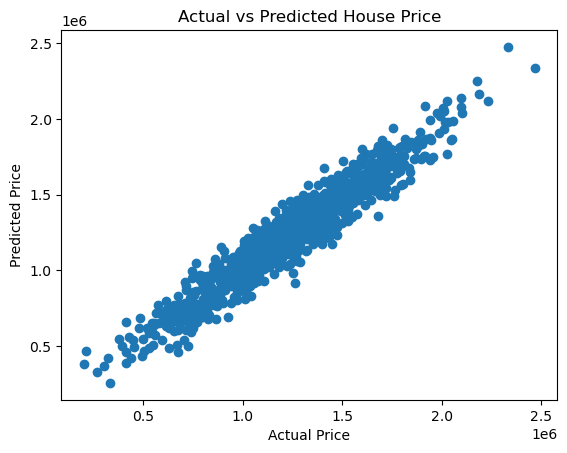

Model saved!


In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle
import matplotlib.pyplot as plt

# 1️⃣ Load dataset
df = pd.read_csv("USA_Housing - Copy.csv")

# 2️⃣ Drop Address column
df = df.drop(['Address'], axis=1)

# 3️⃣ Feature & Target
X = df.drop('Price', axis=1)
y = df['Price']

# 4️⃣ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5️⃣ Model Train
model = LinearRegression()
model.fit(X_train, y_train)

# 6️⃣ Prediction
predictions = model.predict(X_test)

# 7️⃣ Evaluation
print("MAE:", mean_absolute_error(y_test, predictions))
print("MSE:", mean_squared_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

# 8️⃣ Graph
plt.scatter(y_test, predictions)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")
plt.show()

# 9️⃣ Save Model
pickle.dump(model, open("house_price_model.pkl", "wb"))
print("Model saved!")

In [16]:
# 5️⃣ Model Train
model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# 6️⃣ Prediction
predictions = model.predict(X_test)


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle
import matplotlib.pyplot as plt


In [13]:
# 1️⃣ Load dataset
df = pd.read_csv("USA_Housing - Copy.csv")


In [12]:
# 7️⃣ Evaluation
print("MAE:", mean_absolute_error(y_test, predictions))
print("MSE:", mean_squared_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

NameError: name 'y_test' is not defined

In [4]:
# 8️⃣ Graph
plt.scatter(y_test, predictions)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")
plt.show()


NameError: name 'plt' is not defined

In [1]:
# 9️⃣ Save Model
pickle.dump(model, open("house_price_model.pkl", "wb"))
print("Model saved!")

NameError: name 'pickle' is not defined

In [14]:
from flask import Flask, render_template, request
import pickle

app = Flask(__name__)

# Load model (same folder e thakle relative path diye)
with open('house_price_model.pkl', 'rb') as f:
    model = pickle.load(f)

@app.route('/', methods=['GET', 'POST'])
def home():
    prediction = None
    if request.method == 'POST':
        # Example: user input from form
        features = [float(request.form['feature1'])]  # just example
        prediction = model.predict([features])[0]
    return render_template('index.html', prediction=prediction)

if __name__ == '__main__':
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with watchdog (windowsapi)


SystemExit: 1

C:\Users\Puja Sikder\AppData\Roaming\Python\Python312\site-packages\IPython\core\interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
if __name__ == '__main__':
    app.run(debug=True, use_reloader=False)

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [09/Apr/2026 14:41:28] "GET / HTTP/1.1" 500 -
Traceback (most recent call last):
  File "D:\anaconda\Lib\site-packages\flask\app.py", line 1498, in __call__
    return self.wsgi_app(environ, start_response)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\anaconda\Lib\site-packages\flask\app.py", line 1476, in wsgi_app
    response = self.handle_exception(e)
               ^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\anaconda\Lib\site-packages\flask\app.py", line 1473, in wsgi_app
    response = self.full_dispatch_request()
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\anaconda\Lib\site-packages\flask\app.py", line 882, in full_dispatch_request
    rv = self.handle_user_exception(e)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\anaconda\Lib\site-packages\flask\app.py", line 880, in full_dispatch_request
    rv = self.dispatch_request()
         ^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\anaconda\Lib\site-pac

In [ ]:
from flask import Flask, render_template, request
import pickle

app = Flask(__name__)

# Load the model (relative path, same folder)
with open('house_price_model.pkl', 'rb') as f:
    model = pickle.load(f)

@app.route('/', methods=['GET', 'POST'])
def home():
    prediction = None
    if request.method == 'POST':
        # Get value from form input
        try:
            feature = float(request.form['feature1'])  # input name="feature1"
            prediction = model.predict([[feature]])[0]  # model expects 2D array
        except Exception as e:
            prediction = f"Error: {e}"

    return render_template('index.html', prediction=prediction)

if __name__ == '__main__':
    app.run(debug=True)

In [ ]:
from flask import Flask, render_template, request
import pickle
import os

# Ensure relative paths work
BASE_DIR = os.path.dirname(os.path.abspath(__file__))

app = Flask(__name__)

# Load ML model
model_path = os.path.join(BASE_DIR, 'house_price_model.pkl')
with open(model_path, 'rb') as f:
    model = pickle.load(f)

@app.route('/', methods=['GET', 'POST'])
def home():
    prediction = None
    if request.method == 'POST':
        try:
            feature = float(request.form['feature1'])
            prediction = model.predict([[feature]])[0]
        except Exception as e:
            prediction = f"Error: {e}"

    return render_template('index.html', prediction=prediction)

if __name__ == '__main__':
    app.run(debug=True)